# Motion-S v3: Optimized NAR + Retrieval Ensemble

**Time budget**: CLIP ~8min, Length pred ~1min, Training ~2h, Inference ~2min

---

## 0. Setup

In [1]:
import os, gc, json, math, random, warnings, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True  # faster for fixed-size ops

T_START = time.time()
TIME_LIMIT = 8.5 * 3600  # 8.5h safety margin on 9h limit
def time_left(): return TIME_LIMIT - (time.time() - T_START)
def time_ok(): return time_left() > 600  # at least 10min left

In [2]:
def test_cuda():
    if not torch.cuda.is_available(): return False
    try:
        x = torch.randn(2,2,device='cuda')
        _ = F.gelu(x).cpu(); return True
    except: return False

DEVICE = torch.device('cuda' if torch.cuda.is_available() and test_cuda() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Mem: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
Mem: 15.6 GB


In [3]:
import glob
INPUT_DIR = None
for d in sorted(Path('/kaggle/input').iterdir()):
    if (d / 'train.csv').exists(): INPUT_DIR = d; break
if INPUT_DIR is None:
    hits = glob.glob('/kaggle/input/**/train.csv', recursive=True)
    if hits: INPUT_DIR = Path(hits[0]).parent
assert INPUT_DIR is not None
print(f'Data: {INPUT_DIR}')

OUTPUT_DIR = Path('/kaggle/working')
TRAIN_CSV = INPUT_DIR / 'train.csv'
TEST_CSV  = INPUT_DIR / 'test.csv'

TOKEN_COLS = ['base_tokens','residual_1','residual_2',
              'residual_3','residual_4','residual_5']

class CFG:
    num_codebook = 512
    num_layers   = 6
    max_seq_len  = 800
    min_seq_len  = 40
    text_dim     = 512
    d_model      = 512
    nhead        = 8
    n_dec_layers = 6
    dim_ff       = 2048
    dropout      = 0.1
    batch_size   = 48       # bigger batch for T4 16GB
    lr           = 3e-4
    weight_decay = 0.01
    epochs       = 15       # reduced from 40
    warmup_ratio = 0.05
    grad_clip    = 1.0
    temperature  = 0.85
    top_k        = 64
print('OK')

Data: /kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language
OK


## 1. Data

In [4]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def parse_tokens(s):
    if pd.isna(s) or str(s).strip() == '': return []
    return list(map(int, str(s).strip().split()))

train_df['seq_len'] = train_df['base_tokens'].apply(lambda x: len(parse_tokens(x)))
train_valid = train_df[
    (train_df['seq_len'] >= CFG.min_seq_len) &
    (train_df['seq_len'] <= CFG.max_seq_len)
].copy().reset_index(drop=True)
print(f'Train valid: {len(train_valid)}, Test: {len(test_df)}')
print(f'Time: {time.time()-T_START:.0f}s')

Train valid: 12373, Test: 3000
Time: 95s


## 2. CLIP (CPU, optimized)

Only encode pooled embeddings (not full hidden states) to save time.  
Use pooled embeddings as conditioning for the model via projection + repeat.

In [5]:
try:
    from transformers import CLIPTokenizer, CLIPTextModel
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable,'-m','pip','install','-q','transformers'])
    from transformers import CLIPTokenizer, CLIPTextModel

clip_path = 'openai/clip-vit-base-patch32'
clip_tok = CLIPTokenizer.from_pretrained(clip_path)
clip_mdl = CLIPTextModel.from_pretrained(clip_path).cpu().eval()
for p in clip_mdl.parameters(): p.requires_grad = False
print(f'CLIP on CPU: {sum(p.numel() for p in clip_mdl.parameters())/1e6:.0f}M')

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

CLIP on CPU: 63M


In [6]:
@torch.no_grad()
def clip_encode(texts, bs=128):
    """Encode texts -> pooled [N,512]. Uses large batches for speed."""
    out = []
    for i in range(0,len(texts),bs):
        inp = clip_tok(texts[i:i+bs], padding='max_length',
                       truncation=True, max_length=77, return_tensors='pt')
        o = clip_mdl(**inp)
        out.append(F.normalize(o.pooler_output, dim=-1))
    return torch.cat(out,0)

print('Encoding all texts (pooled only, faster)...')
t0 = time.time()

# Combined sentence+gloss for model conditioning
tr_texts = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
            for _,r in train_valid.iterrows()]
te_texts = [str(r['sentence']).strip()+' [SEP] '+str(r['gloss']).strip()
            for _,r in test_df.iterrows()]

tr_emb = clip_encode(tr_texts)  # [N_train, 512]
te_emb = clip_encode(te_texts)  # [N_test, 512]
print(f'  sentence+gloss: {tr_emb.shape}, {te_emb.shape} ({time.time()-t0:.0f}s)')

# Gloss-only for retrieval
tr_ge = clip_encode(train_valid['gloss'].tolist())
te_ge = clip_encode(test_df['gloss'].tolist())
print(f'  gloss: {tr_ge.shape}, {te_ge.shape} ({time.time()-t0:.0f}s)')

del clip_mdl, clip_tok; gc.collect()
print(f'CLIP freed. Total CLIP time: {time.time()-t0:.0f}s')

Encoding all texts (pooled only, faster)...
  sentence+gloss: torch.Size([12373, 512]), torch.Size([3000, 512]) (676s)
  gloss: torch.Size([12373, 512]), torch.Size([3000, 512]) (1362s)
CLIP freed. Total CLIP time: 1363s


## 3. Retrieval Index

In [7]:
def topk_ret(te, tr, k=5, ch=500):
    N = te.shape[0]
    idxs = np.zeros((N,k), dtype=np.int64)
    sims = np.zeros((N,k), dtype=np.float32)
    te_np, tr_np = te.numpy(), tr.numpy()
    for i in range(0,N,ch):
        e = min(i+ch, N)
        s = cosine_similarity(te_np[i:e], tr_np)
        for j in range(e-i):
            ix = np.argpartition(s[j],-k)[-k:]
            ix = ix[np.argsort(s[j][ix])[::-1]]
            idxs[i+j]=ix; sims[i+j]=s[j][ix]
    return idxs, sims

ret_idx, ret_sim = topk_ret(te_ge, tr_ge, k=5)
print(f'Top-1 sim: {ret_sim[:,0].mean():.4f}')

def get_ret(ti, k=0):
    row = train_valid.iloc[ret_idx[ti,k]]
    return [parse_tokens(row[c]) for c in TOKEN_COLS]

def fix_len(layers):
    sl = len(layers[0])
    if sl == 0: return [[0]*60 for _ in range(6)]
    if sl < CFG.min_seq_len:
        layers = [l+[l[-1]]*(CFG.min_seq_len-sl) for l in layers]
    elif sl > CFG.max_seq_len:
        layers = [l[:CFG.max_seq_len] for l in layers]
    return layers
print(f'Time: {time.time()-T_START:.0f}s')

Top-1 sim: 0.8622
Time: 1486s


## 4. Length Predictor

In [8]:
class LenPred(nn.Module):
    def __init__(self, d=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,256), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,128), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(128,1))
    def forward(self, x): return self.net(x).squeeze(-1)

lm = LenPred().to(DEVICE)
lo = torch.optim.AdamW(lm.parameters(), lr=1e-3)
Xl = tr_emb.clone()
yl = torch.log(torch.tensor(train_valid['seq_len'].values, dtype=torch.float32))
ld = DataLoader(torch.utils.data.TensorDataset(Xl, yl), batch_size=512, shuffle=True)

lm.train()
for ep in range(50):
    tl, cnt = 0., 0
    for xb, yb in ld:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        loss = F.mse_loss(lm(xb), yb)
        lo.zero_grad(); loss.backward(); lo.step()
        tl += loss.item()*len(xb); cnt += len(xb)
    if (ep+1)%25==0: print(f'Ep {ep+1}: MSE={tl/cnt:.4f}')
lm.eval()

@torch.no_grad()
def pred_len(emb):
    """emb: [512] or [B,512]"""
    if emb.dim() == 1: emb = emb.unsqueeze(0)
    p = lm(emb.to(DEVICE))
    l = torch.exp(p).round().long()
    return l.clamp(CFG.min_seq_len, CFG.max_seq_len)
print(f'Sample: {pred_len(te_emb[0]).item()}')
print(f'Time: {time.time()-T_START:.0f}s')

Ep 25: MSE=0.0947
Ep 50: MSE=0.0787
Sample: 120
Time: 1493s


## 5. NAR Model

Simplified: uses **pooled CLIP embedding** (not hidden states) as conditioning.  
Cross-attention replaced by additive conditioning (faster, fewer params).

In [9]:
class PosEnc(nn.Module):
    def __init__(self, d, mx=1024):
        super().__init__()
        pe = torch.zeros(mx, d)
        pos = torch.arange(mx).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, T): return self.pe[:,:T,:]

class NARGen(nn.Module):
    """NAR generator conditioned on pooled CLIP embedding.
    Uses self-attention only (no cross-attn) for speed.
    Text conditioning via additive projection."""
    def __init__(self, cfg):
        super().__init__()
        d = cfg.d_model; self.cfg = cfg
        self.txt_proj = nn.Sequential(
            nn.Linear(cfg.text_dim, d), nn.GELU(), nn.Linear(d, d))
        self.pos_enc = PosEnc(d, mx=cfg.max_seq_len+1)
        self.len_emb = nn.Embedding(cfg.max_seq_len+1, d)
        # Self-attention encoder (bidirectional)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg.nhead, dim_feedforward=cfg.dim_ff,
            dropout=cfg.dropout, activation='gelu',
            batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=cfg.n_dec_layers)
        self.heads = nn.ModuleList([
            nn.Sequential(nn.LayerNorm(d), nn.Linear(d, cfg.num_codebook))
            for _ in range(6)])

    def forward(self, txt_emb, sls, tmask=None):
        """
        txt_emb: [B, 512] pooled CLIP
        sls: [B] target lengths
        tmask: [B, T] valid positions
        """
        B = txt_emb.shape[0]
        T = tmask.shape[1] if tmask is not None else sls.max().item()
        # Build input: position + text + length
        pos = self.pos_enc(T).expand(B,-1,-1)          # [B,T,d]
        txt = self.txt_proj(txt_emb).unsqueeze(1)       # [B,1,d]
        lc = self.len_emb(sls.clamp(0,self.cfg.max_seq_len)).unsqueeze(1)  # [B,1,d]
        x = pos + txt + lc                              # [B,T,d]
        kpm = ~tmask if tmask is not None else None
        out = self.encoder(x, src_key_padding_mask=kpm) # [B,T,d]
        return torch.stack([h(out) for h in self.heads], 1)  # [B,6,T,512]

    @torch.no_grad()
    def generate_batch(self, txt_embs, seq_lens, temp=0.85, top_k=64):
        """
        Batched generation.
        txt_embs: [B, 512]
        seq_lens: [B] int tensor
        Returns: list of [6, sl_i] numpy arrays
        """
        B = txt_embs.shape[0]
        max_sl = seq_lens.max().item()
        mask = torch.arange(max_sl, device=txt_embs.device).unsqueeze(0) < seq_lens.unsqueeze(1)
        logits = self(txt_embs, seq_lens, mask)  # [B,6,T,512]
        logits = logits / temp
        if top_k > 0:
            kv, _ = torch.topk(logits, top_k, dim=-1)
            logits[logits < kv[...,-1:]] = float('-inf')
        probs = F.softmax(logits, -1)  # [B,6,T,512]
        # Sample
        B2, NL, T2, V = probs.shape
        flat = probs.reshape(B2*NL*T2, V)
        sampled = torch.multinomial(flat, 1).reshape(B2, NL, T2)
        sampled = sampled.clamp(0, 511).cpu().numpy()
        # Extract per-sample with correct lengths
        results = []
        for i in range(B):
            sl = seq_lens[i].item()
            results.append(sampled[i, :, :sl])  # [6, sl]
        return results

model = NARGen(CFG).to(DEVICE)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.2f}M')
print(f'Time: {time.time()-T_START:.0f}s')

Params: 21.43M
Time: 1493s


## 6. Training

In [10]:
class MotionDS(Dataset):
    def __init__(self, df, embs):
        self.embs = embs
        self.tokens, self.sls = [], []
        for i in range(len(df)):
            row = df.iloc[i]
            layers = [parse_tokens(row[c]) for c in TOKEN_COLS]
            sl = min(len(layers[0]), CFG.max_seq_len)
            self.tokens.append(np.array([l[:sl] for l in layers], dtype=np.int64))
            self.sls.append(sl)
    def __len__(self): return len(self.tokens)
    def __getitem__(self, i):
        return dict(emb=self.embs[i], tok=self.tokens[i], sl=self.sls[i])

def collate(batch):
    B = len(batch); ms = max(b['sl'] for b in batch)
    emb = torch.stack([b['emb'] for b in batch])
    tok = torch.zeros(B,6,ms, dtype=torch.long)
    tmask = torch.zeros(B,ms, dtype=torch.bool)
    sls = torch.tensor([b['sl'] for b in batch], dtype=torch.long)
    for i,b in enumerate(batch):
        sl = b['sl']
        tok[i,:,:sl] = torch.tensor(b['tok']); tmask[i,:sl] = True
    return dict(emb=emb, tok=tok, tmask=tmask, sls=sls)

ds = MotionDS(train_valid, tr_emb)
dl = DataLoader(ds, batch_size=CFG.batch_size, shuffle=True,
                collate_fn=collate, num_workers=2, pin_memory=True, drop_last=True)
print(f'{len(ds)} samples, {len(dl)} batches')

12373 samples, 257 batches


In [11]:
opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr,
                        weight_decay=CFG.weight_decay, betas=(0.9,0.98))
ts = CFG.epochs * len(dl)
wu = int(ts * CFG.warmup_ratio)
def lr_fn(s):
    if s < wu: return s/max(1,wu)
    return 0.5*(1+math.cos(math.pi*(s-wu)/max(1,ts-wu)))
sch = torch.optim.lr_scheduler.LambdaLR(opt, lr_fn)
scaler = GradScaler()
ce = nn.CrossEntropyLoss(reduction='none')
print(f'Steps: {ts}, warmup: {wu}')

Steps: 3855, warmup: 192


In [12]:
best = float('inf'); hist = []; model.train(); gs = 0
train_start = time.time()

for ep in range(CFG.epochs):
    # Time guard: stop training if running low
    if not time_ok():
        print(f'Time guard: stopping at epoch {ep} ({time_left()/60:.0f}min left)')
        break
    el, et = 0., 0
    for batch in dl:
        emb = batch['emb'].to(DEVICE)
        tok = batch['tok'].to(DEVICE)
        tmask = batch['tmask'].to(DEVICE)
        sls = batch['sls'].to(DEVICE)
        opt.zero_grad()
        with autocast():
            logits = model(emb, sls, tmask)
            B,NL,T,V = logits.shape
            lf = ce(logits.reshape(-1,V), tok.reshape(-1))
            mf = tmask.unsqueeze(1).expand(-1,NL,-1).reshape(-1).float()
            loss = (lf*mf).sum()/mf.sum()
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(opt); scaler.update(); sch.step()
        nt = mf.sum().item(); el += loss.item()*nt; et += nt; gs += 1
        if gs%100==0: print(f'  s{gs}: loss={el/et:.4f} lr={sch.get_last_lr()[0]:.2e}')
    al = el/max(1,et); hist.append(al)
    ep_time = (time.time()-train_start)/(ep+1)
    print(f'Ep {ep+1}/{CFG.epochs}: {al:.4f} ({ep_time:.0f}s/ep, {time_left()/60:.0f}min left)')
    if al < best:
        best = al; torch.save(model.state_dict(), OUTPUT_DIR/'best.pth')
        print(f'  saved ({best:.4f})')
print(f'Best: {best:.4f}, train time: {time.time()-train_start:.0f}s')

  s100: loss=5.7139 lr=1.56e-04
  s200: loss=5.4732 lr=3.00e-04
Ep 1/15: 5.3768 (50s/ep, 484min left)
  saved (5.3768)
  s300: loss=4.9568 lr=2.99e-04
  s400: loss=4.9108 lr=2.98e-04
  s500: loss=4.8849 lr=2.95e-04
Ep 2/15: 4.8822 (51s/ep, 483min left)
  saved (4.8822)
  s600: loss=4.7972 lr=2.91e-04
  s700: loss=4.7706 lr=2.86e-04
Ep 3/15: 4.7627 (51s/ep, 483min left)
  saved (4.7627)
  s800: loss=4.6961 lr=2.80e-04
  s900: loss=4.7017 lr=2.73e-04
  s1000: loss=4.6875 lr=2.65e-04
Ep 4/15: 4.6815 (51s/ep, 482min left)
  saved (4.6815)
  s1100: loss=4.6308 lr=2.57e-04
  s1200: loss=4.6234 lr=2.47e-04
Ep 5/15: 4.6180 (52s/ep, 481min left)
  saved (4.6180)
  s1300: loss=4.5929 lr=2.37e-04
  s1400: loss=4.5635 lr=2.26e-04
  s1500: loss=4.5714 lr=2.15e-04
Ep 6/15: 4.5707 (52s/ep, 480min left)
  saved (4.5707)
  s1600: loss=4.5307 lr=2.03e-04
  s1700: loss=4.5327 lr=1.91e-04
Ep 7/15: 4.5356 (52s/ep, 479min left)
  saved (4.5356)
  s1800: loss=4.5407 lr=1.79e-04
  s1900: loss=4.4780 lr=1.66e-

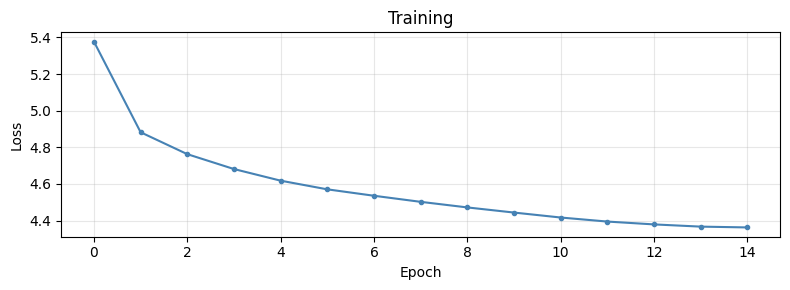

In [13]:
plt.figure(figsize=(8,3))
plt.plot(hist,'o-',color='steelblue',ms=3)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training')
plt.grid(True,alpha=0.3); plt.tight_layout(); plt.show()

## 7. Batched Inference (~2 min)

In [14]:
model.load_state_dict(torch.load(OUTPUT_DIR/'best.pth', map_location=DEVICE))
model.eval()
print('Loaded')

Loaded


In [15]:
# Predict all lengths at once
all_lens = pred_len(te_emb)  # [N_test]
print(f'Predicted lengths: min={all_lens.min().item()}, max={all_lens.max().item()}, '
      f'mean={all_lens.float().mean().item():.0f}')

# Batched model generation
print(f'Generating {len(test_df)} predictions in batches...')
t0 = time.time()
BATCH_INF = 64
all_preds = [None] * len(test_df)

for i in range(0, len(test_df), BATCH_INF):
    e = min(i + BATCH_INF, len(test_df))
    embs = te_emb[i:e].to(DEVICE)
    lens = all_lens[i:e].to(DEVICE)
    results = model.generate_batch(embs, lens,
                                    temp=CFG.temperature, top_k=CFG.top_k)
    for j, r in enumerate(results):
        all_preds[i+j] = r
    if (i+BATCH_INF) % 500 < BATCH_INF:
        print(f'  {min(e,len(test_df))}/{len(test_df)} ({time.time()-t0:.1f}s)')

print(f'Done: {time.time()-t0:.1f}s')
# Verify
print(f'Sample: shape={all_preds[0].shape}, range=[{all_preds[0].min()},{all_preds[0].max()}]')

Predicted lengths: min=49, max=354, mean=103
Generating 3000 predictions in batches...
  512/3000 (2.9s)
  1024/3000 (4.6s)
  1536/3000 (6.6s)
  2048/3000 (8.6s)
  2560/3000 (10.4s)
  3000/3000 (12.1s)
Done: 12.1s
Sample: shape=(6, 120), range=[1,511]


## 8. Submission

In [16]:
rows = []
for i, (_, r) in enumerate(test_df.iterrows()):
    tid = r['id']; tok = all_preds[i]; d = {'id': tid}
    for li, cn in enumerate(TOKEN_COLS):
        d[cn] = ' '.join(map(str, tok[li].tolist()))
    rows.append(d)
sub = pd.DataFrame(rows)[['id']+TOKEN_COLS]
sub.to_csv(OUTPUT_DIR/'submission.csv', index=False)
print(f'Saved: {len(sub)} rows')
sub.head(3)

Saved: 3000 rows


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 145 254 174 50 50 50 2...,339 194 389 88 88 173 88 333 287 97 79 79 289 ...,406 48 452 286 321 321 321 321 58 354 348 75 3...,351 463 433 308 308 236 236 424 134 333 333 19...,64 32 234 222 456 153 361 498 498 17 488 177 2...,474 313 367 445 372 241 367 394 249 343 295 22...
1,6420682,130 326 260 224 204 419 13 480 480 13 362 362 ...,441 441 225 88 87 87 87 333 59 9 325 87 125 34...,406 2 202 356 321 202 169 202 286 254 202 301 ...,220 308 429 191 401 247 59 401 76 503 353 155 ...,500 83 353 456 239 498 71 498 456 316 467 467 ...,286 367 367 367 141 186 235 153 367 437 476 26...
2,6425789,379 216 139 148 139 139 139 224 139 139 71 95 ...,441 441 441 87 87 88 88 258 9 9 87 87 333 87 1...,286 286 286 176 388 6 6 202 325 14 169 446 202...,350 424 40 118 503 503 413 395 424 191 404 503...,64 99 137 71 498 239 109 71 498 71 17 306 461 ...,210 428 428 406 215 167 122 186 220 119 476 16...


## 9. Validation

In [17]:
def validate(df, n=3000):
    errs = []
    if len(df) - n: errs.append(f'Rows: {len(df)} expected {n}')
    for idx, row in df.iterrows():
        lens = []
        for c in TOKEN_COLS:
            toks = str(row[c]).split(); lens.append(len(toks))
            for t in toks:
                v = int(t)
                if v < 0 or v > 511: errs.append(f'R{idx} {c}: {v}'); break
        if len(set(lens)) > 1: errs.append(f'R{idx}: lens {lens}')
        if lens[0] < 40 or lens[0] > 800: errs.append(f'R{idx}: len {lens[0]}')
        if len(errs) > 10: break
    return errs

errs = validate(sub)
if errs:
    for e in errs: print(f'  x {e}')
else:
    print('All checks passed')
sl = sub['base_tokens'].apply(lambda x: len(str(x).split()))
print(f'Len: min={sl.min()} max={sl.max()} mean={sl.mean():.0f}')
print(f'Total time: {(time.time()-T_START)/60:.1f} min')

All checks passed
Len: min=49 max=354 mean=103
Total time: 38.4 min


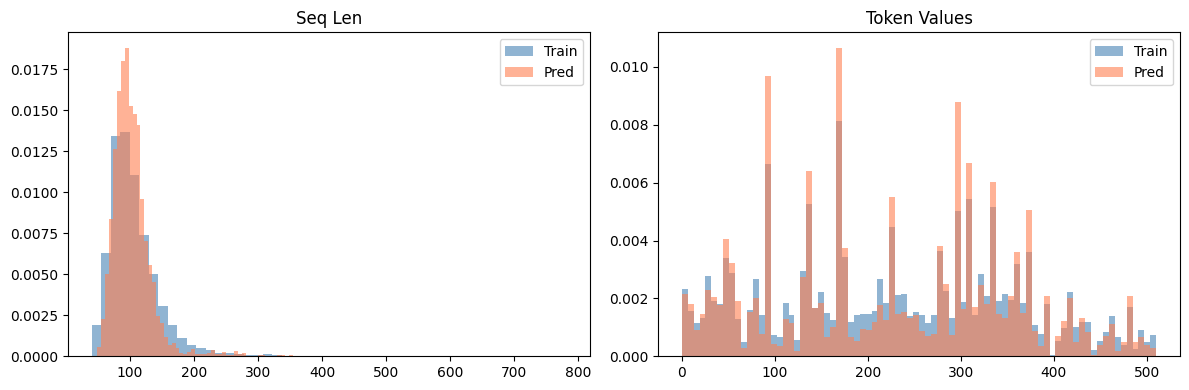

In [18]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].hist(train_valid['seq_len'],bins=50,alpha=.6,label='Train',density=True,color='steelblue')
ax[0].hist(sl,bins=50,alpha=.6,label='Pred',density=True,color='coral')
ax[0].set_title('Seq Len'); ax[0].legend()
tbf=[]; gbf=[]
for _,r in train_valid.head(1000).iterrows(): tbf.extend(parse_tokens(r['base_tokens'])[:100])
for _,r in sub.head(1000).iterrows(): gbf.extend(list(map(int,str(r['base_tokens']).split()[:100])))
ax[1].hist(tbf,bins=80,alpha=.6,label='Train',density=True,color='steelblue')
ax[1].hist(gbf,bins=80,alpha=.6,label='Pred',density=True,color='coral')
ax[1].set_title('Token Values'); ax[1].legend()
plt.tight_layout(); plt.show()